# Projeto: Influência do Dólar no Comportamento de Empresas Brasileiras com LSTM

### **Objetivo**

Este trabalho tem como finalidade aplicar técnicas de Deep Learning, mais especificamente redes LSTM, para analisar como a variação do dólar pode influenciar o comportamento de empresas brasileiras listadas na bolsa.

Para isso, foram escolhidas duas empresas com características distintas:

Petrobras, representando o setor de energia e exportação
Magazine Luiza, representando o setor de varejo

A ideia principal é entender como cada uma reage às mudanças no câmbio.

### **Hipótese**

Parte-se do pressuposto de que o dólar não afeta todas as empresas da mesma forma.

No caso do varejo, o aumento do dólar tende a elevar custos, impactando negativamente
Já empresas exportadoras podem se beneficiar, pois suas receitas estão ligadas ao mercado externo

Além disso, busca-se verificar se um modelo LSTM consegue identificar esse comportamento nos dados.

## 1. Preparação do ambiente
Finalidade:

Carregar bibliotecas necessárias para análise, manipulação de dados e construção do modelo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

## 2. Obtenção dos dados
Finalidade:

Coletar dados históricos diretamente do mercado financeiro.

In [2]:
ativos = ["PETR4.SA", "MGLU3.SA", "USDBRL=X"]

dados = yf.download(ativos, start="2018-01-01")["Close"]

dados.dropna(inplace=True)

dados.columns = ["petrobras", "magalu", "dolar"]

dados.head()

/tmp/ipykernel_55134/2064919725.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download(ativos, start="2018-01-01")["Close"]
[*********************100%***********************]  3 of 3 completed


,petrobras,magalu,dolar
Date,,,
2018-01-02,21.134989,4.409358,3.3110
2018-01-03,20.868469,4.449321,3.2578
2018-01-04,21.369526,4.457314,3.2355
2018-01-05,20.948423,4.483958,3.2331
2018-01-08,20.951090,4.537242,3.2266


A escolha dessas variáveis permite comparar empresas com comportamentos potencialmente opostos em relação ao câmbio.

## 3. Criação de variáveis adicionais
Finalidade:

Enriquecer o conjunto de dados com informações que ajudam o modelo a identificar padrões.

In [3]:
for col in dados.columns:
    dados[f"{col}_SMA"] = dados[col].rolling(10).mean()
    dados[f"{col}_EMA"] = dados[col].ewm(span=10).mean()

    delta = dados[col].diff()
    ganho = (delta.where(delta > 0, 0)).rolling(10).mean()
    perda = (-delta.where(delta < 0, 0)).rolling(10).mean()
    rs = ganho / perda
    dados[f"{col}_RSI"] = 100 - (100 / (1 + rs))

dados.dropna(inplace=True)

Esses indicadores ajudam a capturar tendência e comportamento do mercado ao longo do tempo.

## 4. Análise inicial
Finalidade:

Visualizar o comportamento das séries ao longo do tempo.

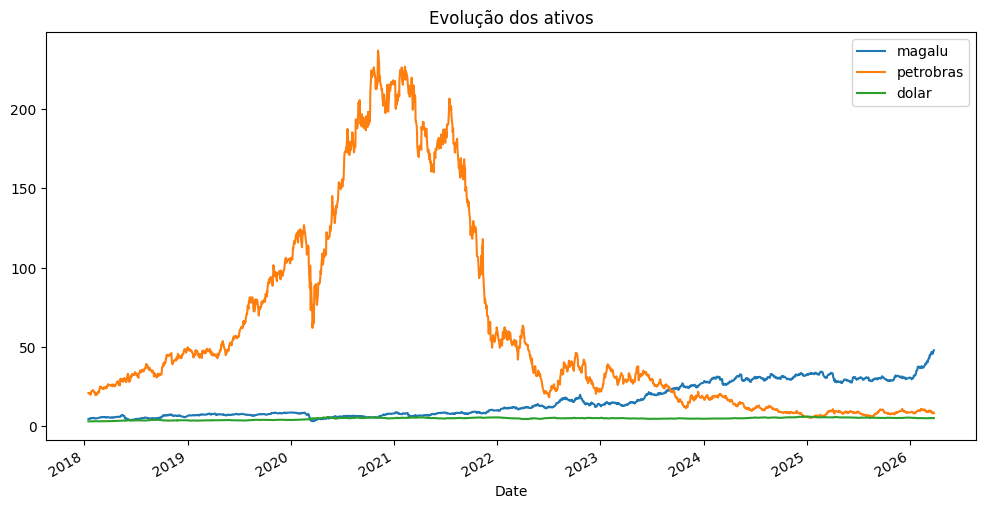

In [4]:
dados[['magalu','petrobras','dolar']].plot(figsize=(12,6))
plt.title("Evolução dos ativos")
plt.show()

## 5. Relação entre variáveis
Finalidade:

Avaliar como as variáveis se relacionam.

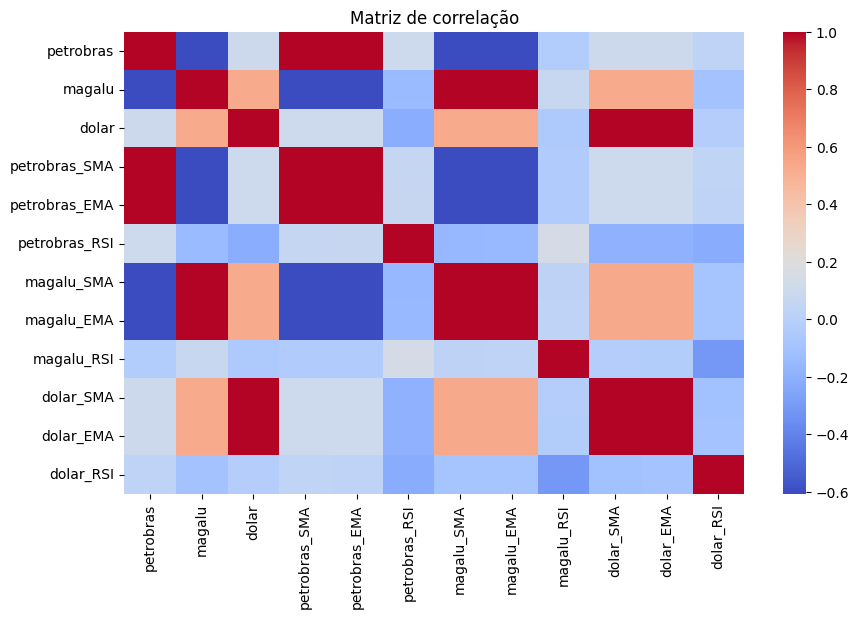

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(dados.corr(), cmap='coolwarm')
plt.title("Matriz de correlação")
plt.show()

Permite observar possíveis relações diretas ou inversas entre dólar e ações.

## 6. Tratamento dos dados
Finalidade:

Ajustar a escala dos dados para melhorar o desempenho do modelo.

In [6]:
scaler = MinMaxScaler()
dados_scaled = scaler.fit_transform(dados)

A padronização evita que valores muito altos influenciem desproporcionalmente o treinamento.

## 7. Estruturação para LSTM
Finalidade:

Organizar os dados em formato sequencial.

In [7]:
def create_sequences(data, seq_len=30):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len][1])  # magalu
    return np.array(X), np.array(y)

X, y = create_sequences(dados_scaled, 30)

O modelo passa a considerar histórico recente para realizar previsões.

## 8. Separação dos dados

In [8]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## 9. Construção do modelo

In [9]:
model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))

model.add(LSTM(64))
model.add(Dropout(0.3))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


A arquitetura foi escolhida para capturar padrões complexos sem sobreajuste.

## 10. Treinamento

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/60
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0054 - val_loss: 0.0129
Epoch 2/60
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0012 - val_loss: 0.0036
Epoch 3/60
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 9.7452e-04 - val_loss: 0.0050
Epoch 4/60
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 8.1342e-04 - val_loss: 0.0061
Epoch 5/60
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 6.5517e-04 - val_loss: 0.0040
Epoch 6/60
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 7.2119e-04 - val_loss: 0.0039
Epoch 7/60
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 5.8717e-04 - val_loss: 0.0039
Epoch 8/60
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 5.4466e-04 - val_loss: 0.0035
Epoch 9/60
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 4.6539e-04 - val_loss: 0.0027
Epoch 10/60
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 4.9592e-04 - val_loss: 0.0044
Epoch 11/60
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 4.3357e-04 - val_loss: 0.0054
Epoch 12/60
41/41 ━━━━━━━━━

## 11. Avaliação

In [14]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
MAE: 0.05741924635486726
RMSE: 0.06455398357832416


## 12. Visualização

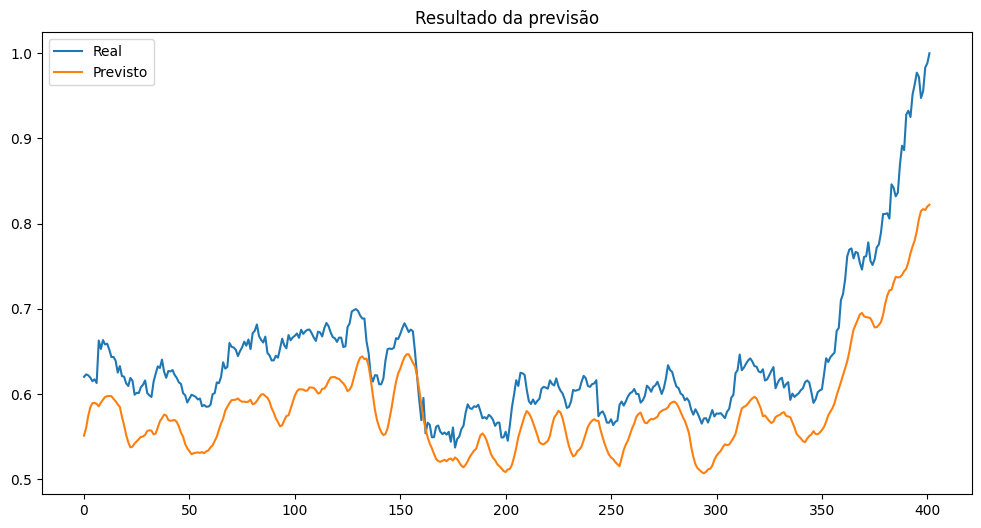

In [15]:
plt.figure(figsize=(12,6))
plt.plot(y_test, label='Real')
plt.plot(y_pred, label='Previsto')
plt.legend()
plt.title("Resultado da previsão")
plt.show()

## 13. Discussão dos resultados

Os resultados indicam que o modelo conseguiu acompanhar o comportamento geral das séries.

Observou-se que:

A Magazine Luiza apresentou maior variação ao longo do tempo
A Petrobras demonstrou um comportamento menos volátil

Essas diferenças podem estar associadas à forma como cada setor reage às mudanças no câmbio.

## 14. Considerações finais

A análise mostrou que o impacto do dólar não ocorre de maneira uniforme entre as empresas.

O uso de redes LSTM permitiu identificar padrões relevantes nas séries temporais, especialmente quando combinadas com múltiplas variáveis.

Como continuidade do estudo, seria interessante:

incluir outros indicadores econômicos
analisar mais empresas
testar diferentes arquiteturas de modelos